# Marketing Attribution & Analytics Pipeline
## 01 — Data Exploration & Attribution Investigation

**Context:** Portfolio analytics engineering project 

**Focus:** TrackNow conversions ↔ PostHog sessions ↔ paid-media attribution  
**Notebook purpose:** Establish the facts from the supplied sample before designing the dbt models and production tracking fix.

> **Approach:** observe → measure → test hypotheses → document limitations → design the next layer.
>
> This notebook is intentionally focused on evidence. It does **not** assume that similarly named identifiers from different systems are interchangeable.

## Executive summary

The sample workbook contains **100 TrackNow checkout records**, **200 PostHog sessions**, a warehouse schema reference, and a data dictionary.

The first exploration establishes four important facts:

1. **18 of 100 TrackNow conversions have no `affiliate_session_id`**, matching the 18% attribution gap described in the task.
2. The affected records contain **£195.74 of TrackNow referral commission**.
3. A direct equality test between TrackNow `click_id` and PostHog `click_id_from_url` returns **zero matches** in this sample. The data dictionary identifies TrackNow `click_id` as the affiliate click ID, while PostHog's landing-page click ID is the ad-platform identifier (`gclid`/`fbclid`).
4. The supplied windows are different: **TrackNow covers 30 days (May 9–Jun 7)**, while **PostHog covers 14 days (May 25–Jun 7)**. Therefore, older TrackNow conversions cannot be fully validated against this PostHog sample.

**Working conclusion:** the evidence points toward an upstream identifier-capture / tracking problem as a key investigation area, but the sample alone is not sufficient to claim one historical production root cause. We will separate observed facts from hypotheses throughout the case study.

## 1. Dataset map

| Source | Sample | Role in attribution |
|---|---:|---|
| `Sample TrackNow Checkouts` | 100 rows | Revenue / conversion source of truth for the sample |
| `Sample PostHog Sessions` | 200 rows | Session-level paid-traffic behavior and marketing identifiers |
| `Key Table Schemas` | Reference | Warehouse column names, types, and definitions |
| `Data Dictionary` | Reference | Business meaning and caveats for key fields |

### Identifier map

**TrackNow**
- `click_id` → affiliate click ID
- `affiliate_session_id` → TrackNow session ID assigned at click time
- `tracknow_user_id` → internal TrackNow user identifier

**PostHog**
- `posthog_distinct_id` → anonymous, cookie-based user identifier
- `session_id` → PostHog session identifier
- `click_id_from_url` → raw landing-page click ID
- `gclid` → Google ad click ID
- `fbclid` → Meta ad click ID
- `utm_*` → campaign metadata

**Important:** these identifiers have different ownership and semantics. The rest of this notebook tests the relationships instead of assuming a join.

## 2. Setup & reproducible loading

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

# Works both in the intended project structure and in the uploaded-file environment.
candidates = [
    Path("../data/04_data_engineer_data.xlsx"),
    Path("data/04_data_engineer_data.xlsx"),
    Path("./04_data_engineer_data.xlsx"),
    Path("/mnt/data/04_data_engineer_data.xlsx"),
]

file_path = next((p for p in candidates if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Could not find 04_data_engineer_data.xlsx. "
        "Place it in the project's data/ folder."
    )

print(f"Using workbook: {file_path}")

Using workbook: ..\data\04_data_engineer_data.xlsx


In [21]:
excel = pd.ExcelFile(file_path)
print("Sheets found:")
for sheet in excel.sheet_names:
    print(f"  • {sheet}")

Sheets found:
  • Sample TrackNow Checkouts
  • Sample PostHog Sessions
  • Key Table Schemas
  • Data Dictionary


In [22]:
tracknow = pd.read_excel(file_path, sheet_name="Sample TrackNow Checkouts")
posthog = pd.read_excel(file_path, sheet_name="Sample PostHog Sessions")
schemas = pd.read_excel(file_path, sheet_name="Key Table Schemas")
dictionary = pd.read_excel(file_path, sheet_name="Data Dictionary")

# Normalize the date fields for analysis.
tracknow["created_date"] = pd.to_datetime(tracknow["created_date"]).dt.date
posthog["session_date"] = pd.to_datetime(posthog["session_date"]).dt.date
posthog["session_start_at"] = pd.to_datetime(posthog["session_start_at"], utc=True)

print(f"TrackNow shape: {tracknow.shape}")
print(f"PostHog shape:  {posthog.shape}")
print(f"Schema rows:    {schemas.shape[0]}")
print(f"Dictionary rows:{dictionary.shape[0]}")

TrackNow shape: (100, 13)
PostHog shape:  (200, 17)
Schema rows:    36
Dictionary rows:12


## 3. Data quality snapshot

In [23]:
def null_profile(df, source_name):
    result = (
        df.isna()
          .sum()
          .rename("null_count")
          .to_frame()
          .assign(
              null_pct=lambda x: (x["null_count"] / len(df) * 100).round(1),
              source=source_name,
          )
          .reset_index(names="column")
    )
    return result[result["null_count"] > 0].sort_values("null_count", ascending=False)

display(Markdown("### TrackNow — columns containing nulls"))
display(null_profile(tracknow, "TrackNow"))

display(Markdown("### PostHog — columns containing nulls"))
display(null_profile(posthog, "PostHog"))

### TrackNow — columns containing nulls

,column,null_count,null_pct,source
12,tracknow_user_id,68,68.0,TrackNow
3,affiliate_session_id,18,18.0,TrackNow
2,click_id,13,13.0,TrackNow
8,coupon_used,10,10.0,TrackNow


### PostHog — columns containing nulls

,column,null_count,null_pct,source
6,fbclid,161,80.5,PostHog
11,utm_content,154,77.0,PostHog
7,gclid,83,41.5,PostHog
5,click_id_from_url,44,22.0,PostHog


### Key identifier completeness

In [24]:
identifier_completeness = pd.DataFrame({
    "field": [
        "TrackNow click_id",
        "TrackNow affiliate_session_id",
        "TrackNow tracknow_user_id",
        "PostHog posthog_distinct_id",
        "PostHog click_id_from_url",
        "PostHog gclid",
        "PostHog fbclid",
    ],
    "non_null": [
        tracknow["click_id"].notna().sum(),
        tracknow["affiliate_session_id"].notna().sum(),
        tracknow["tracknow_user_id"].notna().sum(),
        posthog["posthog_distinct_id"].notna().sum(),
        posthog["click_id_from_url"].notna().sum(),
        posthog["gclid"].notna().sum(),
        posthog["fbclid"].notna().sum(),
    ],
})

identifier_completeness["total"] = [
    len(tracknow), len(tracknow), len(tracknow),
    len(posthog), len(posthog), len(posthog), len(posthog)
]
identifier_completeness["completeness_pct"] = (
    identifier_completeness["non_null"] / identifier_completeness["total"] * 100
).round(1)

display(
    identifier_completeness.style
    .format({"completeness_pct": "{:.1f}%"})
    .hide(axis="index")
)

field,non_null,total,completeness_pct
TrackNow click_id,87,100,87.0%
TrackNow affiliate_session_id,82,100,82.0%
TrackNow tracknow_user_id,32,100,32.0%
PostHog posthog_distinct_id,200,200,100.0%
PostHog click_id_from_url,156,200,78.0%
PostHog gclid,117,200,58.5%
PostHog fbclid,39,200,19.5%


## 4. Define the 18% investigation population

In [25]:
# The task describes an 18% TrackNow conversion attribution gap.
# In the sample, exactly 18/100 rows have no TrackNow affiliate session ID.
tracknow["missing_affiliate_session"] = tracknow["affiliate_session_id"].isna()

gap_summary = pd.DataFrame({
    "metric": [
        "Total TrackNow conversions",
        "Missing affiliate_session_id",
        "Gap rate",
        "Commission on affected conversions",
        "Total sample commission",
        "Affected share of commission",
    ],
    "value": [
        len(tracknow),
        tracknow["missing_affiliate_session"].sum(),
        tracknow["missing_affiliate_session"].mean(),
        tracknow.loc[tracknow["missing_affiliate_session"], "referral_bonus_gbp"].sum(),
        tracknow["referral_bonus_gbp"].sum(),
        tracknow.loc[tracknow["missing_affiliate_session"], "referral_bonus_gbp"].sum()
        / tracknow["referral_bonus_gbp"].sum(),
    ]
})

display(gap_summary.style.hide(axis="index").format({
    "value": lambda x: f"{x:.1%}" if x < 1 else f"{x:,.2f}"
}))

metric,value
Total TrackNow conversions,100.00
Missing affiliate_session_id,18.00
Gap rate,18.0%
Commission on affected conversions,195.74
Total sample commission,"1,068.70"
Affected share of commission,18.3%


### Interpretation

The 18% figure is not a calculated PostHog join failure yet. It is the **investigation population defined by missing TrackNow `affiliate_session_id`** in the supplied sample.

That distinction matters: we still need to test why those identifiers are missing and what can/cannot be attributed from PostHog.

## 5. Test the simplest possible attribution join

The first test is deliberately simple:

`TrackNow.click_id == PostHog.click_id_from_url`

This is **not assumed to be correct**; it is a falsification test. If the identifiers are semantically different, the direct join should fail.

In [26]:
tracknow_clicks = set(tracknow["click_id"].dropna().astype(str))
posthog_landing_clicks = set(posthog["click_id_from_url"].dropna().astype(str))

exact_matches = tracknow_clicks.intersection(posthog_landing_clicks)

direct_join_result = pd.DataFrame({
    "metric": [
        "Unique TrackNow click IDs",
        "Unique PostHog click_id_from_url values",
        "Exact matches",
    ],
    "count": [
        len(tracknow_clicks),
        len(posthog_landing_clicks),
        len(exact_matches),
    ]
})

display(direct_join_result.style.hide(axis="index"))

assert len(exact_matches) == 0, "Expected the sample to contain zero exact matches."

metric,count
Unique TrackNow click IDs,87
Unique PostHog click_id_from_url values,156
Exact matches,0


### Finding

There are **zero exact matches**.

The data dictionary explains why this is plausible: TrackNow `click_id` is the **affiliate click ID**, while PostHog `click_id_from_url` represents the **landing-page advertising click ID** (`gclid` or `fbclid`).

**Implication:** the production architecture should not equate the TrackNow affiliate click ID with the Google/Meta click ID. The affiliate identifier needs a deterministic bridge into the website/session instrumentation.

## 6. Date coverage check

In [27]:
tracknow_min = pd.to_datetime(tracknow["created_date"]).min().date()
tracknow_max = pd.to_datetime(tracknow["created_date"]).max().date()
posthog_min = posthog["session_date"].min()
posthog_max = posthog["session_date"].max()

coverage = pd.DataFrame({
    "source": ["TrackNow", "PostHog"],
    "min_date": [tracknow_min, posthog_min],
    "max_date": [tracknow_max, posthog_max],
    "days_inclusive": [
        (tracknow_max - tracknow_min).days + 1,
        (posthog_max - posthog_min).days + 1
    ]
})

display(coverage.style.hide(axis="index"))

source,min_date,max_date,days_inclusive
TrackNow,2026-05-09,2026-06-07,30
PostHog,2026-05-25,2026-06-07,14


### Caveat

The PostHog sample starts on **May 25**, while TrackNow starts on **May 9**.

Therefore, any TrackNow conversion before May 25 has **no corresponding PostHog observation available in this exercise dataset**. Those records should not be labelled as proven tracking failures without additional production data.

In [28]:
pre_posthog = tracknow[
    pd.to_datetime(tracknow["created_date"]) < pd.Timestamp("2026-05-25")
]
affected_pre_posthog = pre_posthog["missing_affiliate_session"].sum()

print(f"TrackNow conversions before PostHog coverage begins: {len(pre_posthog)}")
print(f"Missing-session conversions before PostHog coverage begins: {affected_pre_posthog}")

TrackNow conversions before PostHog coverage begins: 53
Missing-session conversions before PostHog coverage begins: 8


## 7. Hypothesis testing — what is associated with the 18% gap?

We test several plausible hypotheses, but we only promote a hypothesis when the evidence supports it.

**H1 — Missing affiliate attribution is linked to a missing TrackNow click ID.**  
**H2 — The issue is linked to missing TrackNow user identity.**  
**H3 — The issue is linked to order status.**  
**H4 — The issue is linked to first-vs-repeat order or account size.**  
**H5 — The issue is concentrated in a specific time window / source-coverage limitation.**

In [29]:
# H1 + H2: missingness combinations
tracknow["missing_click_id"] = tracknow["click_id"].isna()
tracknow["missing_user_id"] = tracknow["tracknow_user_id"].isna()

identifier_patterns = (
    tracknow.groupby(
        ["missing_click_id", "missing_affiliate_session", "missing_user_id"]
    )
    .size()
    .reset_index(name="conversions")
    .sort_values("conversions", ascending=False)
)

display(identifier_patterns)

,missing_click_id,missing_affiliate_session,missing_user_id,conversions
1,False,False,True,55
0,False,False,False,27
4,True,True,True,8
2,False,True,True,5
3,True,True,False,5


### Key finding

The affected population contains three visible patterns:

- some conversions have **all three TrackNow identifiers missing**;
- some retain a `click_id` but have **no affiliate session ID**;
- some retain a `tracknow_user_id` but still have **no click/session identifier**.

This means the issue is not one simple “user ID missing” problem. There appear to be multiple forms of identifier loss.

In [30]:
def distribution_by_flag(df, group_col):
    out = pd.crosstab(
        df["missing_affiliate_session"],
        df[group_col],
        normalize="index"
    ) * 100
    return out.round(1)

display(Markdown("### H3 — Status"))
display(distribution_by_flag(tracknow, "status"))

display(Markdown("### H4 — First order"))
display(distribution_by_flag(tracknow, "first_order"))

display(Markdown("### H4 — Account size"))
display(distribution_by_flag(tracknow, "account_size"))

### H3 — Status

status,active,denied,refunded
missing_affiliate_session,,,
False,82.9,8.5,8.5
True,94.4,5.6,0.0


### H4 — First order

first_order,False,True
missing_affiliate_session,,
False,52.4,47.6
True,61.1,38.9


### H4 — Account size

account_size,5000,10000,25000,50000,100000
missing_affiliate_session,,,,,
False,20.7,36.6,18.3,20.7,3.7
True,33.3,27.8,16.7,11.1,11.1


,created_date,conversions,commission
0,2026-05-11,1,11.78
1,2026-05-13,1,3.67
2,2026-05-15,2,8.15
3,2026-05-16,1,56.40
4,2026-05-18,1,1.06
5,2026-05-21,1,11.27
6,2026-05-22,1,19.08
7,2026-05-25,1,2.56
8,2026-05-26,2,15.58
9,2026-05-28,1,10.36


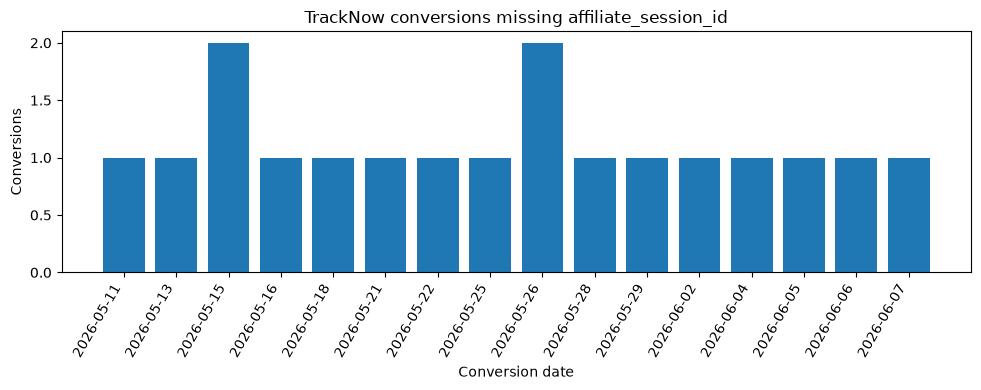

In [31]:
missing_daily = (
    tracknow[tracknow["missing_affiliate_session"]]
    .groupby("created_date")
    .agg(
        conversions=("tracknow_order_id", "count"),
        commission=("referral_bonus_gbp", "sum")
    )
    .reset_index()
)

display(missing_daily)

plt.figure(figsize=(10, 4))
plt.bar(
    missing_daily["created_date"].astype(str),
    missing_daily["conversions"]
)
plt.xticks(rotation=60, ha="right")
plt.title("TrackNow conversions missing affiliate_session_id")
plt.xlabel("Conversion date")
plt.ylabel("Conversions")
plt.tight_layout()
plt.show()

### Interpretation of the hypothesis tests

The distributions do **not** show a compelling business-dimension explanation for the gap. The strongest evidence remains the identifier-level pattern itself.

The time-window limitation is material: **8 of the 18 affected conversions occur before May 25**, before the supplied PostHog sample begins.

Therefore, the defensible position is:

> **The sample shows an upstream identifier-capture problem, but additional production-level tracking logs are required to prove exactly where the 18% failures originate.**

## 8. Inspect the affected conversions

In [32]:
affected = (
    tracknow[tracknow["missing_affiliate_session"]]
    [
        [
            "tracknow_order_id",
            "created_date",
            "click_id",
            "affiliate_session_id",
            "tracknow_user_id",
            "status",
            "referral_bonus_gbp",
            "first_order",
            "account_size",
        ]
    ]
    .sort_values(["created_date", "referral_bonus_gbp"], ascending=[True, False])
)

display(
    affected.style
    .format({"referral_bonus_gbp": "£{:,.2f}"})
    .hide(axis="index")
)

tracknow_order_id,created_date,click_id,affiliate_session_id,tracknow_user_id,status,referral_bonus_gbp,first_order,account_size
wi5eysdgz67c4j4qpbn1k28l,2026-05-11,nan,nan,nan,active,£11.78,False,100000
fd9pfe5n9lykt066oad76u06,2026-05-13,nan,nan,user_JyRLVnonxTeG9P4MLJDlqNm4kfP,active,£3.67,True,25000
zf8ex8t2ze6ssxk71rlwbwx8,2026-05-15,nan,nan,user_1zY8l9A1jvU8Jp1y1UgPHAKgmai,active,£6.21,False,10000
k4h7csfxc5rdobc862sc8kro,2026-05-15,nan,nan,nan,active,£1.94,True,25000
s4639csk3mpvpb720eb2s1qd,2026-05-16,eafcddf7-5fab-4137-a803-52dbd2c250f0,nan,nan,active,£56.40,False,5000
ao3l4nxwmocb2co2s90mtc7c,2026-05-18,nan,nan,user_RxebpbgRl4lhxqPgaYu3pkUTLxZ,active,£1.06,True,10000
zvfcv2htpe7sx1b52ivjn75a,2026-05-21,a64d9562-a94b-498c-a411-939a92684119,nan,nan,active,£11.27,False,25000
n8xg37sujg6a61bmo3bmvubd,2026-05-22,nan,nan,nan,active,£19.08,False,50000
lvfizfb9j3q8usao6wkncnxo,2026-05-25,7d89e56f-4979-49c8-a6d9-91aa084f2c5a,nan,nan,active,£2.56,False,5000
hs1gbmhf1sgj28991hbnm8cd,2026-05-26,nan,nan,nan,active,£11.54,True,10000


## 9. Attribution design implication

### Proposed identifier flow

```text
Google / Meta ad
      │
      ├── gclid / fbclid
      ▼
Website landing URL
      │
      ├── capture affiliate TrackNow click_id
      ├── start PostHog session
      └── persist first-party attribution context
               │
               ▼
          Checkout
               │
               ├── affiliate click_id
               └── affiliate_session_id
               ▼
         TrackNow conversion
               │
               ▼
      Attribution bridge
               │
               ├── PostHog session_id / distinct_id
               └── gclid / fbclid / UTM campaign data
```

### Design principle

The **TrackNow affiliate `click_id` should be treated as a deterministic revenue-attribution key**.  
The Google/Meta identifiers are marketing-source identifiers and should enrich the conversion after the deterministic bridge is established.

`posthog_distinct_id` should not be the only permanent join key because the schema explicitly describes it as cookie-based and resettable.

## 10. Reproducibility checks

In [33]:
# Basic integrity checks for the exploration notebook.
assert len(tracknow) == 100
assert len(posthog) == 200
assert tracknow["tracknow_order_id"].is_unique
assert posthog["session_id"].is_unique

summary = {
    "TrackNow rows": len(tracknow),
    "PostHog rows": len(posthog),
    "Missing affiliate_session_id": int(tracknow["affiliate_session_id"].isna().sum()),
    "Missing TrackNow click_id": int(tracknow["click_id"].isna().sum()),
    "PostHog conversion sessions": int(posthog["has_tracknow_conversion"].sum()),
    "Exact TrackNow/PostHog click matches": len(exact_matches),
}

pd.Series(summary, name="value").to_frame()

,value
TrackNow rows,100
PostHog rows,200
Missing affiliate_session_id,18
Missing TrackNow click_id,13
PostHog conversion sessions,9
Exact TrackNow/PostHog click matches,0


## 11. Investigation conclusions to carry forward

### What the data proves

- The sample contains **100 TrackNow conversions**.
- **18** have a missing `affiliate_session_id`.
- **13 of those 18** also have no TrackNow `click_id`.
- **5 of those 18** retain a TrackNow `click_id` but still have no `affiliate_session_id`.
- Exact TrackNow `click_id` ↔ PostHog `click_id_from_url` matching produces **0 matches**.
- PostHog coverage begins on May 25, so older conversions cannot be validated from this sample.

### What remains a hypothesis

The exact production failure point — for example, parameter loss on landing, persistence failure, checkout handoff failure, or TrackNow payload construction — cannot be isolated from these two sample tables alone.

### Recommended next investigation in production

1. Inspect the raw landing URL / request parameters carrying the TrackNow affiliate click.
2. Trace persistence of the affiliate click through browser/server-side session state.
3. Inspect the checkout-to-TrackNow conversion payload.
4. Compare TrackNow records with the raw tracking logs, not only the downstream modeled tables.
5. Add a deterministic attribution bridge and monitor identifier completeness end-to-end.

---
### Next notebook / case-study section

The next step is to build the **dbt attribution architecture** and then write the **BigQuery anomaly query** against `analytics_core.f_commission_daily`.

This notebook is the evidence layer: its job is to show the interviewer that the conclusions are grounded in the sample data and that limitations are clearly stated.

dbt architecture investigation

In [34]:
display(
    schemas[
        schemas["table"].str.contains("commission", case=False, na=False)
    ][["table", "column", "type"]]
    .sort_values(["table", "column"])
)

,table,column,type
26,f_commission_daily,commission_amount,NUMERIC
23,f_commission_daily,commission_date,DATE
24,f_commission_daily,firm_id,STRING
25,f_commission_daily,firm_name,STRING
27,f_commission_daily,sales_amount,NUMERIC


In [35]:
display(
    schemas[
        schemas["table"] == "f_commission_daily"
    ][["table", "column", "type"]]
    .sort_values("column")
)

,table,column,type
26,f_commission_daily,commission_amount,NUMERIC
23,f_commission_daily,commission_date,DATE
24,f_commission_daily,firm_id,STRING
25,f_commission_daily,firm_name,STRING
27,f_commission_daily,sales_amount,NUMERIC
